# Análise Exploratória de Dados

In [50]:
import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
# ── Configurações de Plotagem ────────────────────────────────────────────────
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

In [52]:
# Carrega o dataset Iris como um DataFrame
dados = load_iris(as_frame=True)
iris = dados.frame

iris.head()      # primeiras linhas (matriz de dados)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [53]:
# Converte o alvo numérico (0/1/2) para os nomes das especies
iris["species"] = pd.Categorical.from_codes(dados.target, dados.target_names)
iris = iris.drop(columns="target")

iris.head()     # primeiras linhas (matriz de dados)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [54]:
print(iris.shape)       # (150, 5) -> n x (d+alvo)

(150, 5)


## Medidas de Tendência Central e de Posição

In [55]:
# Tendencia central, dispersao e quartis de cada atributo
iris.describe()  # count, mean, std, min, 25%, 50%, 75%, max

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [57]:
num = iris.select_dtypes(include="number")    #Seleciona apenas dados numéricops
print("-"*50)
print("Média")
print("-"*50)
print(num.mean())          # media

--------------------------------------------------
Média
--------------------------------------------------
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64


In [58]:
print("-"*50)
print("Mediana")
print("-"*50)
print(num.median())        # mediana

--------------------------------------------------
Mediana
--------------------------------------------------
sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64


## Medidas de Dispersão

In [59]:
print("-"*50)
print("Desvio Padrão")
print("-"*50)
print(num.std())           # desvio padrao (amostral)

--------------------------------------------------
Desvio Padrão
--------------------------------------------------
sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [60]:
print("-"*50)
print("Variância")
print("-"*50)
print(num.var())           # variancia

--------------------------------------------------
Variância
--------------------------------------------------
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [61]:
print("-"*50)
print("Amplitude Interquatílica")
print("-"*50)
Q1 = num.quantile(0.25)
Q3 = num.quantile(0.75)
print(Q3 - Q1)

--------------------------------------------------
Amplitude Interquatílica
--------------------------------------------------
sepal length (cm)    1.3
sepal width (cm)     0.5
petal length (cm)    3.5
petal width (cm)     1.5
dtype: float64


## Medidas de Distribuição (Forma)

In [62]:
print("-"*50)
print("Assimetria")
print("-"*50)
print(num.skew())

--------------------------------------------------
Assimetria
--------------------------------------------------
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64


In [63]:
print("-"*50)
print("Excesso de Curtose")
print("-"*50)
print(num.kurt())          # EXCESSO de curtose

--------------------------------------------------
Excesso de Curtose
--------------------------------------------------
sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64


In [64]:
print("-"*50)
print("Deteção de Outliers")
print("-"*50)
lim_inf = Q1 - 1.5 * (Q3 - Q1)
lim_sup = Q3 + 1.5 * (Q3 - Q1)

outliers = (num < lim_inf) | (num > lim_sup)
print(outliers.sum())      # nº de outliers por atributo

--------------------------------------------------
Deteção de Outliers
--------------------------------------------------
sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64


## Representações Gráficas

### Histograma

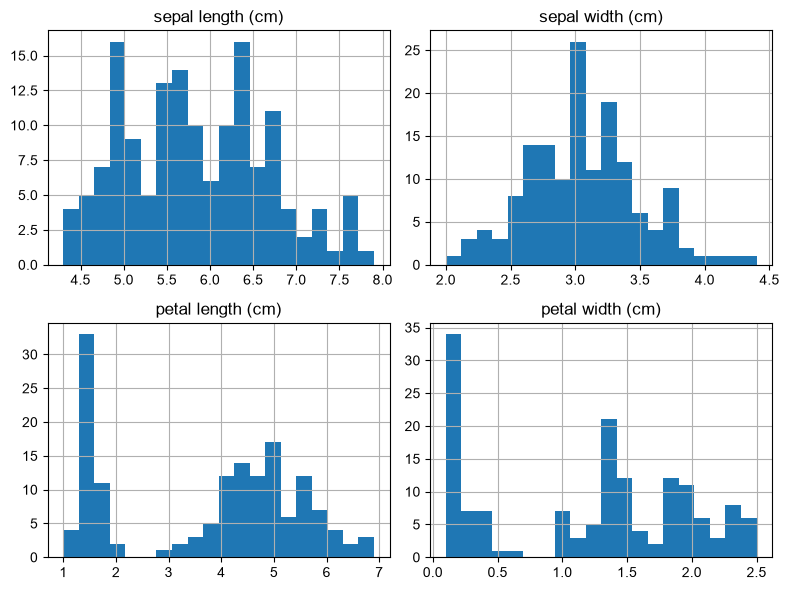

In [65]:
# Histograma de todos os atributos numericos
num.hist(bins=20, figsize=(8, 6))
plt.tight_layout()
plt.show()

### Boxplots

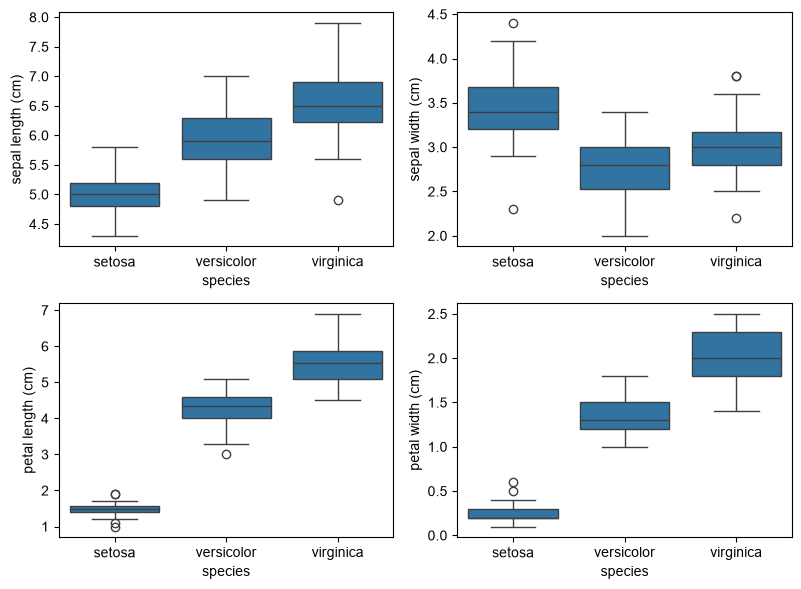

In [71]:
plt.figure(figsize=(8, 6))
for idx in range(4):
    plt.subplot(2, 2, idx + 1)          # idx+1 -> 1,2,3,4 (subplot comeca em 1)
    col = iris.columns[idx]
    sns.boxplot(data=iris, x="species", y=col)

plt.tight_layout()
plt.show()

### Gráficos de Dispersão

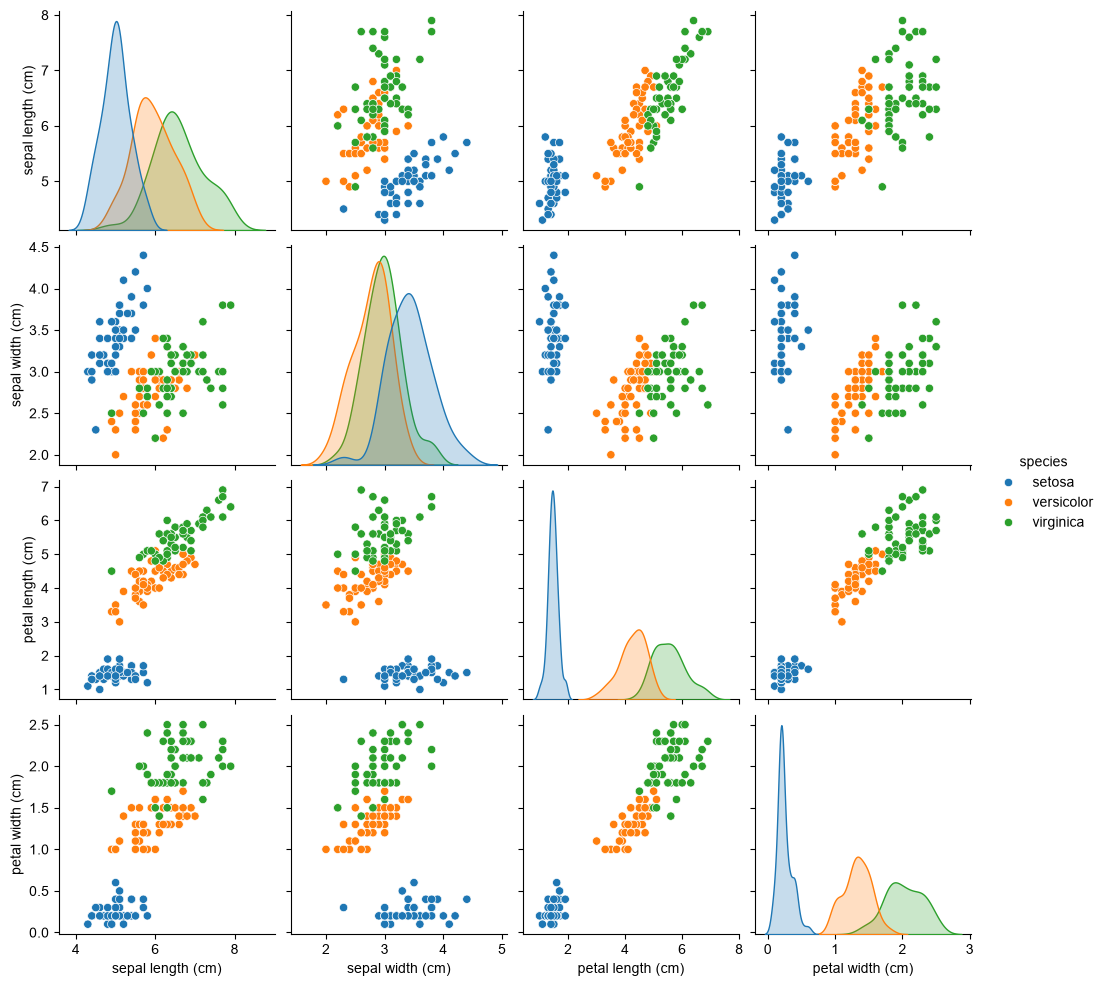

In [72]:
sns.pairplot(iris, hue="species")
plt.show()

### Heatmap

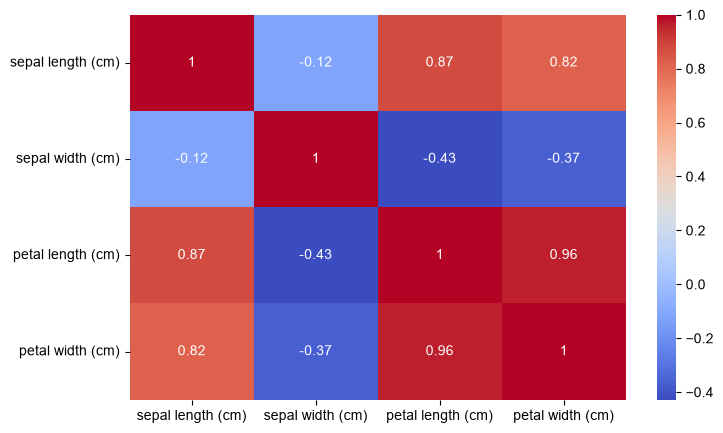

In [73]:
corr = num.corr() 
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()